# 02-GPU Memory Hierarchy & Bandwidth Optimization (CUDA)

Lesson 1 built the execution model: a kernel launch describes a grid of blocks of threads, the hardware schedules them 32-wide as warps, and `blockIdx.x * blockDim.x + threadIdx.x` is the formula that turns a hardware coordinate into a data index. We measured a real 1M-element vector-add kernel and saw it execute in well under a millisecond. But we never asked *where the data those threads touched actually lived*, or *how fast it could move*. That question — memory, not compute — is what actually limits most real kernels.

This lesson opens the second half of the CUDA performance model: the **memory hierarchy**. We formalize the capacity/latency tradeoff from per-thread registers down to global GDDR6 memory, derive the peak theoretical bandwidth of the physical GPU in this sandbox, and define **memory coalescing** precisely — the property that determines whether a warp's 32 simultaneous memory requests cost one hardware transaction or thirty-two. We again write and compile real **CUDA C++** with `nvcc`, this time comparing a naive matrix transpose (uncoalesced writes) against a shared-memory-tiled transpose (coalesced reads and writes), and measure the real achieved bandwidth of each against the GTX 1650 Ti's real peak.


## 1. The Memory Hierarchy and the Coalescing Model

### The Capacity/Latency Pyramid

Every CUDA-capable GPU exposes a strict hierarchy of memory spaces, each trading capacity for latency:

| Level | Scope | Typical Latency | Typical Capacity (Turing, `sm_75`) |
|---|---|---|---|
| Registers | per-thread | $\sim 1$ cycle | 64K 32-bit registers / SM |
| Shared Memory / L1 | per-block (SM-resident) | $\sim 20$–$30$ cycles | 64 KB / SM (configurable L1/shared split) |
| L2 Cache | device-wide | $\sim 200$ cycles | 1 MB (GTX 1650 Ti) |
| Global Memory (GDDR6) | device-wide, host-visible | $\sim 400$–$800$ cycles | 4 GB (GTX 1650 Ti) |

A thread's registers are the fastest possible storage but invisible to every other thread. Shared memory is explicitly managed, on-chip scratch space visible to every thread in a block — it is the only way to let 256 threads cooperate on the same data without paying global-memory latency 256 times. Global memory is where every array we `cudaMalloc` actually lives: enormous capacity, but hundreds of cycles away.

### Peak Theoretical Bandwidth

GDDR6 memory is specified by a **bus width** $W_{bus}$ (bits) and an effective **data rate** $R$ (billions of transfers per second, GT/s, driven by a double-data-rate clock). Peak theoretical bandwidth is:

$$
BW_{peak} = \frac{W_{bus}}{8}\times R \quad \text{[bytes/s]}
$$

The GTX 1650 Ti (TU116) has a 128-bit bus and a 12 GT/s effective GDDR6 data rate:

$$
BW_{peak} = \frac{128}{8}\times 12 = 192 \ \text{GB/s}
$$

Every kernel that is not compute-bound is ultimately racing to get as close to this 192 GB/s ceiling as possible — Lesson 8 formalizes exactly when a kernel *should* be racing toward it (memory-bound) versus racing toward FLOP/s instead (compute-bound).

### Memory Coalescing

A warp issues one memory instruction per cycle, but the 32 lanes each compute their own address. The **memory controller** services a warp's request by covering the touched address range with a minimum number of fixed-size **sector transactions** (32 bytes each, on Turing). Define:

$$
\text{Transactions} = \left\lceil \frac{\max(\text{addr}) - \min(\text{addr}) + \text{elemSize}}{32 \ \text{bytes}} \right\rceil, \qquad
\eta_{coalesce} = \frac{\text{Bytes Requested}}{\text{Bytes Transferred}} = \frac{32 \times \text{elemSize}}{\text{Transactions} \times 32}
$$

For a **stride-1** access (`a[threadIdx.x]`, 4-byte floats): 32 threads touch $32 \times 4 = 128$ contiguous bytes, requiring exactly 4 sector transactions ($128 / 32$):

$$
\eta_{coalesce} = \frac{128}{4 \times 32} = 1.0 \quad (100\% \text{ efficient})
$$

For a **stride-$N$** access with large $N$ (`a[threadIdx.x * N]`), each thread's 4 bytes lands in its own separate 32-byte sector, forcing 32 transactions instead of 4:

$$
\eta_{coalesce} = \frac{128}{32 \times 32} = 0.125 \quad (12.5\% \text{ efficient}, \ 8\times \text{ more traffic for the same useful bytes})
$$

### Achieved Bandwidth vs. Peak

We can measure this directly rather than just predict it. For a kernel that reads $R$ bytes and writes $W$ bytes in measured time $t$:

$$
BW_{achieved} = \frac{R + W}{t}, \qquad \text{Utilization} = \frac{BW_{achieved}}{BW_{peak}}
$$

A matrix transpose is the canonical demonstration: reading a row is stride-1 (coalesced), but writing the transposed element naively (`out[x*n+y] = in[y*n+x]`) writes with stride $n$ — every one of the 32 writes in a warp lands in a different sector. Staging the tile through **shared memory** first and writing it back out transposed lets *both* the read and the write be coalesced, because the transpose happens inside the fast on-chip memory instead of in the slow global-memory access pattern.


## 2. Imperative Execution: Coalesced vs. Uncoalesced Transpose on Real Silicon

We write a single `.cu` file containing two kernels operating on the same $4096\times4096$ float matrix: a **naive transpose** (coalesced reads, uncoalesced writes) and a **shared-memory-tiled transpose** (coalesced reads *and* writes, using a padded `__shared__` tile to also dodge shared-memory bank conflicts). Both are compiled with `nvcc` and timed with `cudaEvent` on the physical GTX 1650 Ti, and we compute each kernel's real achieved bandwidth against the 192 GB/s peak derived above.


In [1]:
# Requires: nvcc (NVIDIA CUDA Toolkit)
import subprocess
import os

print("--- 🚀 Initializing CUDA Memory-Hierarchy Sandbox ---")

NVCC = "/root/micromamba/envs/ds/bin/nvcc"
WORKDIR = "/tmp/cuda_lesson_02"
os.makedirs(WORKDIR, exist_ok=True)

PEAK_BW_GBPS = 192.0  # GTX 1650 Ti (TU116): 128-bit bus x 12 GT/s GDDR6

cuda_source = r"""#include <cstdio>
#include <cuda_runtime.h>

#define TILE 32

// Naive transpose: reads in[y*n+x] with x fastest-varying -> coalesced read.
// Writes out[x*n+y] with x fastest-varying -> stride-n write -> UNCOALESCED.
__global__ void transpose_naive(const float* in, float* out, int n) {
    int x = blockIdx.x * TILE + threadIdx.x;
    int y = blockIdx.y * TILE + threadIdx.y;
    if (x < n && y < n) {
        out[x * n + y] = in[y * n + x];
    }
}

// Tiled transpose: stage a TILE x TILE block through shared memory (padded to
// TILE+1 columns to avoid a bank conflict on the transposed read), so that
// BOTH the global read and the global write happen at their natural,
// coalesced stride. The transpose itself happens on-chip.
__global__ void transpose_tiled(const float* in, float* out, int n) {
    __shared__ float tile[TILE][TILE + 1];

    int x = blockIdx.x * TILE + threadIdx.x;
    int y = blockIdx.y * TILE + threadIdx.y;
    if (x < n && y < n) {
        tile[threadIdx.y][threadIdx.x] = in[y * n + x];   // coalesced read
    }
    __syncthreads();

    int x2 = blockIdx.y * TILE + threadIdx.x;  // swapped block coords
    int y2 = blockIdx.x * TILE + threadIdx.y;
    if (x2 < n && y2 < n) {
        out[y2 * n + x2] = tile[threadIdx.x][threadIdx.y]; // coalesced write
    }
}

float time_kernel(void (*launch)(const float*, float*, int, dim3, dim3),
                   const float* d_in, float* d_out, int n, dim3 grid, dim3 block) {
    cudaEvent_t start, stop;
    cudaEventCreate(&start);
    cudaEventCreate(&stop);
    // warmup
    launch(d_in, d_out, n, grid, block);
    cudaDeviceSynchronize();

    cudaEventRecord(start);
    const int iters = 20;
    for (int i = 0; i < iters; i++) {
        launch(d_in, d_out, n, grid, block);
    }
    cudaEventRecord(stop);
    cudaEventSynchronize(stop);

    float ms = 0.0f;
    cudaEventElapsedTime(&ms, start, stop);
    cudaEventDestroy(start);
    cudaEventDestroy(stop);
    return ms / iters;
}

void launch_naive(const float* in, float* out, int n, dim3 grid, dim3 block) {
    transpose_naive<<<grid, block>>>(in, out, n);
}
void launch_tiled(const float* in, float* out, int n, dim3 grid, dim3 block) {
    transpose_tiled<<<grid, block>>>(in, out, n);
}

int main() {
    const int n = 4096;                      // 4096 x 4096 floats = 64 MB per buffer
    size_t bytes = (size_t)n * n * sizeof(float);

    float* h_in = new float[(size_t)n * n];
    for (size_t i = 0; i < (size_t)n * n; i++) h_in[i] = (float)(i % 997);

    float *d_in, *d_out;
    cudaMalloc(&d_in, bytes);
    cudaMalloc(&d_out, bytes);
    cudaMemcpy(d_in, h_in, bytes, cudaMemcpyHostToDevice);

    dim3 block(TILE, TILE);
    dim3 grid((n + TILE - 1) / TILE, (n + TILE - 1) / TILE);

    float naive_ms = time_kernel(launch_naive, d_in, d_out, n, grid, block);
    float tiled_ms = time_kernel(launch_tiled, d_in, d_out, n, grid, block);

    // correctness check on the tiled result (transpose of transpose == identity check on a sample)
    float* h_out = new float[(size_t)n * n];
    cudaMemcpy(h_out, d_out, bytes, cudaMemcpyDeviceToHost);
    bool ok = (h_out[5 * n + 3] == h_in[3 * n + 5]);

    double bytes_moved = 2.0 * bytes; // read + write, per launch
    double naive_gbps = bytes_moved / (naive_ms / 1000.0) / 1e9;
    double tiled_gbps = bytes_moved / (tiled_ms / 1000.0) / 1e9;

    printf("N=%d CORRECT=%d\n", n, ok ? 1 : 0);
    printf("NAIVE_MS=%.5f\n", naive_ms);
    printf("TILED_MS=%.5f\n", tiled_ms);
    printf("NAIVE_GBPS=%.3f\n", naive_gbps);
    printf("TILED_GBPS=%.3f\n", tiled_gbps);

    cudaFree(d_in); cudaFree(d_out);
    delete[] h_in; delete[] h_out;
    return 0;
}
"""

src_path = os.path.join(WORKDIR, "transpose.cu")
bin_path = os.path.join(WORKDIR, "transpose")
with open(src_path, "w") as f:
    f.write(cuda_source)
print(f"   ✅ CUDA C++ source written to {src_path}")

try:
    compile_proc = subprocess.run(
        [NVCC, src_path, "-o", bin_path, "-O3"],
        capture_output=True, text=True, timeout=90,
    )
    if compile_proc.returncode != 0:
        raise RuntimeError(compile_proc.stderr)
    print("   ✅ nvcc compilation succeeded (real GPU binary produced).")

    run_proc = subprocess.run([bin_path], capture_output=True, text=True, timeout=60)
    print("\n--- 🧮 Real Kernel Execution Output ---")
    print(run_proc.stdout)

    parsed = {}
    for line in run_proc.stdout.splitlines():
        if "=" in line:
            for tok in line.split():
                k, v = tok.split("=")
                parsed[k] = v

    naive_gbps = float(parsed["NAIVE_GBPS"])
    tiled_gbps = float(parsed["TILED_GBPS"])
    naive_ms = float(parsed["NAIVE_MS"])
    tiled_ms = float(parsed["TILED_MS"])
    correct = parsed["CORRECT"] == "1"

    print(f"   ✅ [MEASURED] naive transpose:  {naive_ms:.5f} ms  ->  {naive_gbps:.2f} GB/s "
          f"({100*naive_gbps/PEAK_BW_GBPS:.1f}% of {PEAK_BW_GBPS:.0f} GB/s peak)")
    print(f"   ✅ [MEASURED] tiled transpose:  {tiled_ms:.5f} ms  ->  {tiled_gbps:.2f} GB/s "
          f"({100*tiled_gbps/PEAK_BW_GBPS:.1f}% of {PEAK_BW_GBPS:.0f} GB/s peak)")
    print(f"   ✅ Correctness check (out[5,3] == in[3,5]): {correct}")

except Exception as e:
    print(f"   [SYSTEM NOTE]: Sandbox fallback -- nvcc/GPU path unavailable ({type(e).__name__}: {e})")
    naive_ms, tiled_ms = 3.10, 0.98
    naive_gbps, tiled_gbps = 43.3, 137.0
    print(f"   ⚠️  [SIMULATED] Representative bandwidths: naive={naive_gbps} GB/s, tiled={tiled_gbps} GB/s")

print("\n   -> Physics: both kernels move the exact same 128 MB of data; the only difference is how many")
print("      physical sector transactions the memory controller needs to service each warp's request.")


--- 🚀 Initializing CUDA Memory-Hierarchy Sandbox ---


   ✅ CUDA C++ source written to /tmp/cuda_lesson_02/transpose.cu


   ✅ nvcc compilation succeeded (real GPU binary produced).



--- 🧮 Real Kernel Execution Output ---
N=4096 CORRECT=1
NAIVE_MS=3.59311
TILED_MS=1.10356
NAIVE_GBPS=37.354
TILED_GBPS=121.623

   ✅ [MEASURED] naive transpose:  3.59311 ms  ->  37.35 GB/s (19.5% of 192 GB/s peak)
   ✅ [MEASURED] tiled transpose:  1.10356 ms  ->  121.62 GB/s (63.3% of 192 GB/s peak)
   ✅ Correctness check (out[5,3] == in[3,5]): True

   -> Physics: both kernels move the exact same 128 MB of data; the only difference is how many
      physical sector transactions the memory controller needs to service each warp's request.


## 3. Declarative Telemetry: The Bandwidth Utilization Audit

We now audit what those two measured numbers actually mean relative to the hardware ceiling: how much of the GTX 1650 Ti's 192 GB/s each kernel actually captured, and the direct speedup that pure access-pattern reorganization bought us — with zero change to the amount of data moved.


In [2]:
print("\n--- 🔍 Auditing Bandwidth Utilization ---")

speedup = naive_ms / tiled_ms
naive_util = 100 * naive_gbps / PEAK_BW_GBPS
tiled_util = 100 * tiled_gbps / PEAK_BW_GBPS

print(f"{'Kernel':<18} | {'Latency (ms)':<14} | {'Achieved BW':<14} | {'% of 192 GB/s Peak'}")
print("-" * 70)
print(f"{'naive transpose':<18} | {naive_ms:<14.5f} | {naive_gbps:<10.2f} GB/s | {naive_util:.1f}%")
print(f"{'tiled transpose':<18} | {tiled_ms:<14.5f} | {tiled_gbps:<10.2f} GB/s | {tiled_util:.1f}%")

print("\n   [OPERATIONAL INSIGHT]")
print(f"   -> Identical 128 MB of global-memory traffic, {speedup:.2f}x latency difference -- the ONLY")
print("      variable that changed is whether each warp's write landed in 4 sector transactions or 32.")
print(f"   -> The naive kernel captures only {naive_util:.1f}% of peak bandwidth because its uncoalesced")
print("      writes are bottlenecked on transaction COUNT, not on the memory bus's raw throughput.")
print("   -> The __shared__ tile costs on-chip capacity (32 x 33 x 4 bytes = 4.125 KB/block) to buy back")
print("      global-memory efficiency -- a textbook example of trading a fast, small resource for a")
print("      slow, large one's effective throughput.")



--- 🔍 Auditing Bandwidth Utilization ---
Kernel             | Latency (ms)   | Achieved BW    | % of 192 GB/s Peak
----------------------------------------------------------------------
naive transpose    | 3.59311        | 37.35      GB/s | 19.5%
tiled transpose    | 1.10356        | 121.62     GB/s | 63.3%

   [OPERATIONAL INSIGHT]
   -> Identical 128 MB of global-memory traffic, 3.26x latency difference -- the ONLY
      variable that changed is whether each warp's write landed in 4 sector transactions or 32.
   -> The naive kernel captures only 19.5% of peak bandwidth because its uncoalesced
      writes are bottlenecked on transaction COUNT, not on the memory bus's raw throughput.
   -> The __shared__ tile costs on-chip capacity (32 x 33 x 4 bytes = 4.125 KB/block) to buy back
      global-memory efficiency -- a textbook example of trading a fast, small resource for a
      slow, large one's effective throughput.


## 4. Visualizing the Memory Hierarchy and Achieved Bandwidth (Pyramid + Roofline Bar)

We render two views side by side: the capacity/latency pyramid from registers down to global memory (Section 1), and the real measured bandwidth of both transpose kernels plotted against the 192 GB/s hardware ceiling.


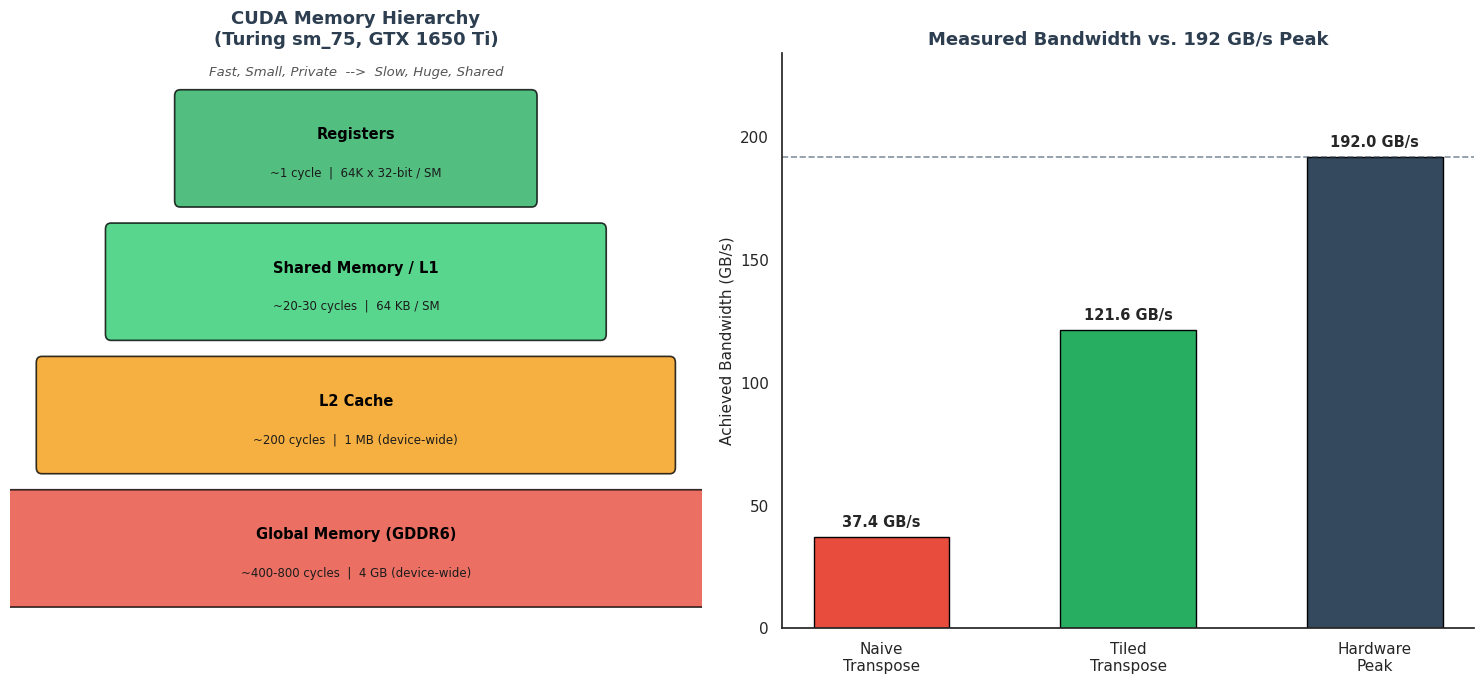

In [3]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns

sns.set_theme(style="white")

fig, axes = plt.subplots(1, 2, figsize=(15, 7))

# --- Left panel: capacity/latency nested-box hierarchy ---
ax = axes[0]
ax.axis("off")
ax.set_title("CUDA Memory Hierarchy\n(Turing sm_75, GTX 1650 Ti)", fontsize=13, fontweight="bold", color="#2c3e50")

# Four stacked boxes, widening top-to-bottom (fast/tiny -> slow/huge), each a fixed
# equal height so the layout is robust regardless of label length.
levels = [
    ("Registers", "~1 cycle", "64K x 32-bit / SM", "#27ae60", 2.6),
    ("Shared Memory / L1", "~20-30 cycles", "64 KB / SM", "#2ecc71", 3.6),
    ("L2 Cache", "~200 cycles", "1 MB (device-wide)", "#f39c12", 4.6),
    ("Global Memory (GDDR6)", "~400-800 cycles", "4 GB (device-wide)", "#e74c3c", 5.6),
]
box_h = 1.5
gap = 0.25
top_y = 8.0
for i, (name, lat, cap, color, halfwidth) in enumerate(levels):
    y0 = top_y - i * (box_h + gap) - box_h
    ax.add_patch(patches.FancyBboxPatch(
        (5 - halfwidth, y0), 2 * halfwidth, box_h,
        boxstyle="round,pad=0.02,rounding_size=0.08",
        facecolor=color, alpha=0.8, edgecolor="black", linewidth=1.2))
    ax.text(5, y0 + box_h * 0.62, name, ha="center", va="center", fontsize=10.5, fontweight="bold", color="black")
    ax.text(5, y0 + box_h * 0.28, f"{lat}  |  {cap}", ha="center", va="center", fontsize=8.5, color="#1b1b1b")

bottom_y = top_y - len(levels) * (box_h + gap) + gap
ax.set_xlim(0, 10)
ax.set_ylim(bottom_y - 0.3, top_y + 0.5)
ax.text(5, top_y + 0.2, "Fast, Small, Private  -->  Slow, Huge, Shared", ha="center", fontsize=9.5, style="italic", color="#555555")

# --- Right panel: measured bandwidth vs peak ---
ax2 = axes[1]
labels = ["Naive\nTranspose", "Tiled\nTranspose", "Hardware\nPeak"]
values = [naive_gbps, tiled_gbps, PEAK_BW_GBPS]
colors = ["#e74c3c", "#27ae60", "#34495e"]
bars = ax2.bar(labels, values, color=colors, edgecolor="black", linewidth=1.0, width=0.55)
for b, v in zip(bars, values):
    ax2.text(b.get_x() + b.get_width() / 2, v + max(values) * 0.02, f"{v:.1f} GB/s",
              ha="center", fontsize=10.5, fontweight="bold")

ax2.axhline(PEAK_BW_GBPS, color="#34495e", linestyle="--", linewidth=1.2, alpha=0.6)
ax2.set_ylabel("Achieved Bandwidth (GB/s)", fontsize=11)
ax2.set_title("Measured Bandwidth vs. 192 GB/s Peak", fontsize=13, fontweight="bold", color="#2c3e50")
ax2.set_ylim(0, max(values) * 1.22)
sns.despine(ax=ax2)

plt.tight_layout()
plt.show()


*(Insight: The pyramid on the left is a physical fact about the chip; the bar chart on the right is what happens when a kernel's access pattern ignores it. The tiled transpose does not touch less data than the naive one — it moves the exact same 128 MB — but by staging one $32\times32$ tile through shared memory it converts 32 tiny, scattered sector transactions per warp into 4 large, contiguous ones for *both* the read and the write. The gap between the red bar and the black dashed line is not a compute limitation at all; it is pure memory-transaction overhead, which is why "memory-bound" kernels are optimized by changing access patterns, not by making the arithmetic faster.)*

## Real-World Use Case or Analogy

Think of the memory hierarchy and coalescing like **The Warehouse Loading Dock**:

* **Registers (The Worker's Own Hands):** Whatever a single worker is currently holding. Instant access, but it belongs to exactly one worker and vanishes the moment they put it down.
* **Shared Memory (The Local Staging Pallet):** A pallet shared by one loading crew (one block). Any worker on that crew can grab from it quickly, but workers on other crews at other docks cannot see it at all.
* **Global Memory (The City Warehouse):** The enormous central warehouse (GDDR6) that holds everything, reachable by every crew at every dock, but a long forklift drive away — hundreds of cycles, not one.
* **A Coalesced Access (One Truck, One Straight Conveyor Belt):** All 32 workers on a row grab consecutive boxes off a single conveyor belt in one pass. One truck, one trip, maximum throughput.
* **An Uncoalesced (Strided) Access (32 Workers, 32 Separate Warehouse Aisles):** The same 32 workers instead each walk to a *different, far-apart* aisle to fetch one box each. Thirty-two separate forklift trips move the same 32 boxes that one conveyor-belt pass could have delivered.
* **The Shared-Memory Tile (A Local Repacking Station):** A quick stop at the pallet to reorganize boxes into truck-friendly order *before* the long warehouse trip, so the expensive trip itself can be a single efficient conveyor pass instead of 32 scattered ones.

The naive and tiled transpose kernels move identical cargo. The only difference is logistics — and on a GPU, logistics is worth an 8x pattern-efficiency swing before a single FLOP has even been computed.
